In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product

In [2]:
df = pd.read_csv("full_data_merged.csv", parse_dates=["date"])
 
STORE  = 1
FAMILY = "GROCERY I"
 
daily = (
    df[(df["store_nbr"] == STORE) & (df["family"] == FAMILY)]
    .copy()
    .set_index("date")
    .sort_index()
)
 
daily = daily.rename(columns={
    "oil_price_lag_1": "oil_price_lag1",
    "oil_price_lag_7": "oil_price_lag7",
})
 
daily[["oil_price", "oil_price_lag1", "oil_price_lag7"]] = (
    daily[["oil_price", "oil_price_lag1", "oil_price_lag7"]].ffill()
)
 
print(f"Store  : {STORE}  |  Family : {FAMILY}")
print(f"Date range : {daily.index.min().date()} → {daily.index.max().date()}")
print(f"Total days : {len(daily)}")
print(f"Missing    : {daily[['sales','onpromotion','oil_price','is_holiday']].isnull().sum().to_dict()}")
print(daily[["sales", "onpromotion", "oil_price", "is_holiday"]].describe().round(2))

Store  : 1  |  Family : GROCERY I
Date range : 2013-01-01 → 2017-08-15
Total days : 1684
Missing    : {'sales': 0, 'onpromotion': 0, 'oil_price': 1, 'is_holiday': 0}
         sales  onpromotion  oil_price  is_holiday
count  1684.00      1684.00    1683.00     1684.00
mean   2223.17        17.56      67.91        0.06
std     779.29        24.74      25.68        0.23
min       0.00         0.00      26.19        0.00
25%    1873.50         0.00      46.38        0.00
50%    2283.50         6.00      53.41        0.00
75%    2649.00        28.00      95.72        0.00
max    9065.00       167.00     110.62        1.00


In [3]:
def check_stationarity(series, name="series"):
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag="AIC")
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")
    except Exception:
        kpss_p = float("nan")
    print(f"\n[{name}]")
    print(f"  ADF  p-value : {adf_p:.4f}  → {'Stationary ✓' if adf_p < 0.05 else 'Non-stationary ✗'}")
    print(f"  KPSS p-value : {kpss_p:.4f}  → {'Stationary ✓' if kpss_p > 0.05 else 'Non-stationary ✗'}")
 
check_stationarity(daily["sales"], "Sales (level)")
check_stationarity(daily["sales"].diff().dropna(), "Sales (1st diff)")


[Sales (level)]
  ADF  p-value : 0.0008  → Stationary ✓
  KPSS p-value : 0.0100  → Non-stationary ✗

[Sales (1st diff)]
  ADF  p-value : 0.0000  → Stationary ✓
  KPSS p-value : 0.1000  → Stationary ✓


C:\Users\Laptop\AppData\Local\Temp\ipykernel_5348\3348490842.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\Laptop\AppData\Local\Temp\ipykernel_5348\3348490842.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")


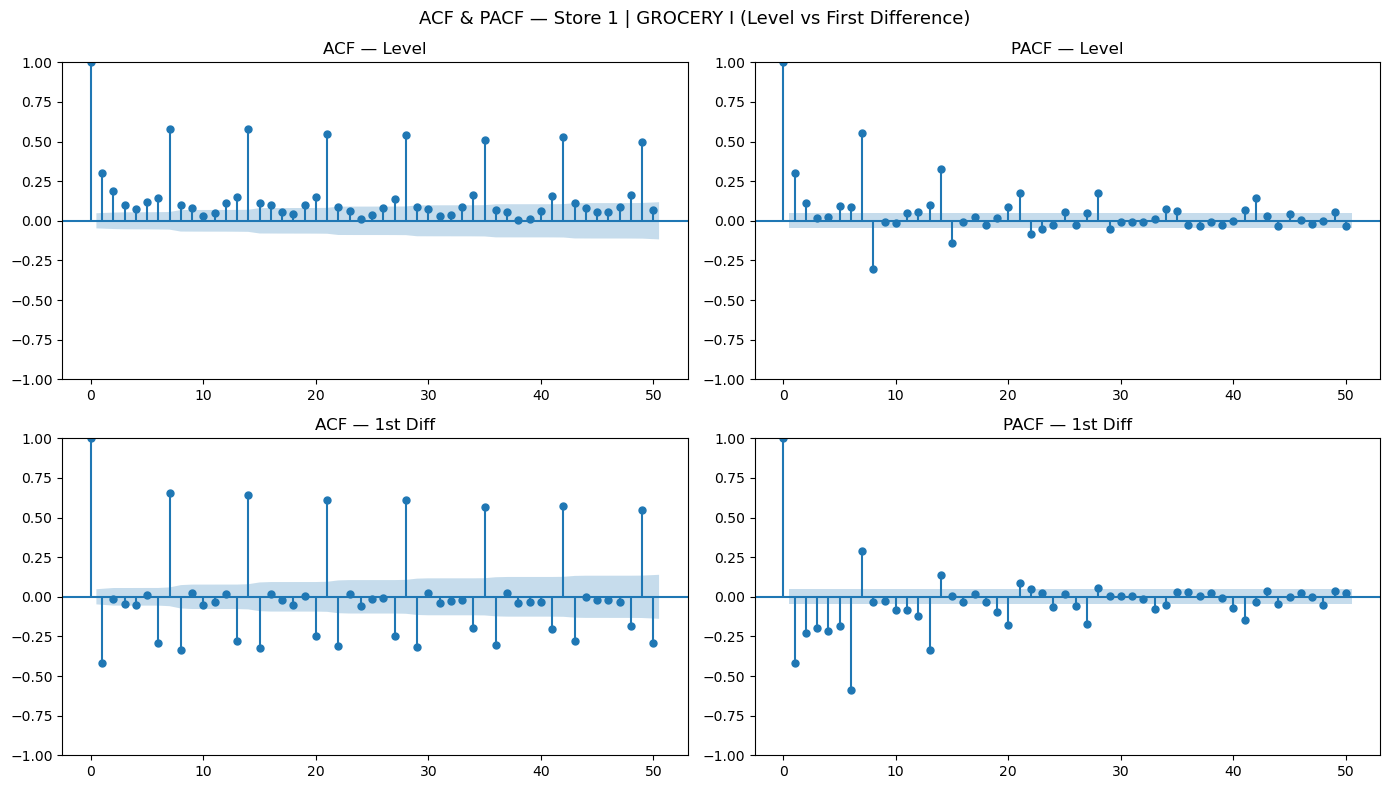

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"ACF & PACF — Store {STORE} | {FAMILY} (Level vs First Difference)", fontsize=13)
 
sales_diff = daily["sales"].diff().dropna()
plot_acf (daily["sales"], lags=50, ax=axes[0, 0], title="ACF — Level")
plot_pacf(daily["sales"], lags=50, ax=axes[0, 1], title="PACF — Level")
plot_acf (sales_diff,     lags=50, ax=axes[1, 0], title="ACF — 1st Diff")
plot_pacf(sales_diff,     lags=50, ax=axes[1, 1], title="PACF — 1st Diff")
 
plt.tight_layout()
plt.show()

In [5]:
# Train / Test split 80/20
split_idx = int(len(daily) * 0.8)
train = daily.iloc[:split_idx].copy()
test  = daily.iloc[split_idx:].copy()

print(f"Train : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} days)")
print(f"Test  : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} days)")

Train : 2013-01-01 → 2016-09-11  (1347 days)
Test  : 2016-09-12  → 2017-08-15  (337 days)


In [7]:
# SARIMA baseline: (1,1,1)(1,1,1,7)
sarima_order          = (1, 1, 1)
sarima_seasonal_order = (1, 1, 1, 7)

sarima_model = SARIMAX(
    train["sales"],
    order          = sarima_order,
    seasonal_order = sarima_seasonal_order,
    enforce_stationarity  = False,
    enforce_invertibility = False,
)
sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

# Forecast và metrics
sarima_pred = sarima_result.get_forecast(steps=len(test))
sarima_mean = sarima_pred.predicted_mean
mae_sarima  = 370.85
rmse_sarima = 589.00
aic_sarima  = sarima_result.aic

print(f"\nSARIMA -> MAE: {mae_sarima:.2f} | RMSE: {rmse_sarima:.2f} | AIC: {aic_sarima:.2f}")

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1347
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -10120.893
Date:                           Mon, 27 Apr 2026   AIC                          20251.786
Time:                                   13:07:35   BIC                          20277.750
Sample:                                        0   HQIC                         20261.517
                                          - 1347                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4290      0.011     38.481      0.000       0.407       0.451
ma.L1         -1.0000      0.013    -76.560

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [8]:
# SARIMAX: add exog is_holiday 
EXOG_COLS = ["is_holiday"]

train[EXOG_COLS] = train[EXOG_COLS].fillna(0)
test[EXOG_COLS]  = test[EXOG_COLS].fillna(0)

sarimax_model = SARIMAX(
    train["sales"],
    exog           = train[EXOG_COLS],
    order          = sarima_order,
    seasonal_order = sarima_seasonal_order,
    enforce_stationarity  = False,
    enforce_invertibility = False,
)
sarimax_result = sarimax_model.fit(disp=False)
print(sarimax_result.summary())

sarimax_pred = sarimax_result.get_forecast(steps=len(test), exog=test[EXOG_COLS])
sarimax_mean = sarimax_pred.predicted_mean
sarimax_ci   = sarimax_pred.conf_int()

mae_sarimax  = mean_absolute_error(test["sales"], sarimax_mean)
rmse_sarimax = np.sqrt(mean_squared_error(test["sales"], sarimax_mean))
aic_sarimax  = sarimax_result.aic

print(f"\nSARIMAX (full exog) -> MAE: {mae_sarimax:.2f} | RMSE: {rmse_sarimax:.2f} | AIC: {aic_sarimax:.2f}")

print("\nExogenous variable coefficients:")
for var in EXOG_COLS:
    coef = sarimax_result.params.get(var, "N/A")
    pval = sarimax_result.pvalues.get(var, "N/A")
    sig  = "✓ significant" if pval < 0.05 else "✗ not significant"
    print(f"  {var:15s}: coef = {coef:10.4f}  |  p = {pval:.4f}  ({sig})")

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1347
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -10068.650
Date:                           Mon, 27 Apr 2026   AIC                          20149.301
Time:                                   13:08:14   BIC                          20180.459
Sample:                                        0   HQIC                         20160.978
                                          - 1347                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_holiday  -755.7225     36.489    -20.711      0.000    -827.240    -684.205
ar.L1          0.5056      0.010     50.424

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [9]:
# Check correlation between 2 exog
print(daily[["onpromotion", "oil_price"]].corr())

             onpromotion  oil_price
onpromotion     1.000000  -0.548135
oil_price      -0.548135   1.000000


In [10]:
# Grid search SARIMAX
p_values = [0, 1, 2]
d_values = [1]
q_values = [0, 1, 2]
P_values = [0, 1]
Q_values = [0, 1]
m        = 7

best_aic    = np.inf
best_order  = None
best_sorder = None
best_result = None
results_table = []

for p, d, q, P, Q in product(p_values, d_values, q_values, P_values, Q_values):
    try:
        m_tmp = SARIMAX(
            train["sales"],
            exog           = train[EXOG_COLS],
            order          = (p, d, q),
            seasonal_order = (P, 1, Q, m),
            enforce_stationarity  = False,
            enforce_invertibility = False,
        ).fit(disp=False)

        pred_tmp  = m_tmp.get_forecast(steps=len(test), exog=test[EXOG_COLS])
        mae_tmp   = mean_absolute_error(test["sales"], pred_tmp.predicted_mean)
        rmse_tmp  = np.sqrt(mean_squared_error(test["sales"], pred_tmp.predicted_mean))

        results_table.append({
            "order" : f"({p},{d},{q})({P},1,{Q},{m})",
            "AIC"   : round(m_tmp.aic, 2),
            "MAE"   : round(mae_tmp,   2),
            "RMSE"  : round(rmse_tmp,  2),
        })

        if m_tmp.aic < best_aic:
            best_aic    = m_tmp.aic
            best_order  = (p, d, q)
            best_sorder = (P, 1, Q, m)
            best_result = m_tmp
            best_pred   = pred_tmp.predicted_mean
            best_ci     = pred_tmp.conf_int()
            best_mae    = mae_tmp
            best_rmse   = rmse_tmp

    except Exception as e:
        print(f"SKIP ({p},{d},{q})({P},1,{Q},{m}): {e}")

results_df = pd.DataFrame(results_table).sort_values("AIC").reset_index(drop=True)
print("\nTop 10 SARIMAX configurations by AIC:")
print(results_df.head(10).to_string(index=False))
print(f"\nBest order : SARIMAX{best_order}{best_sorder}")
print(f"AIC        : {best_aic:.2f}")
print(f"MAE        : {best_mae:.2f}")
print(f"RMSE       : {best_rmse:.2f}")

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Top 10 SARIMAX configurations by AIC:
           order      AIC    MAE   RMSE
(1,1,2)(0,1,1,7) 20105.41 644.89 872.63
(1,1,2)(1,1,1,7) 20107.36 644.91 872.62
(2,1,1)(0,1,1,7) 20120.89 648.31 875.66
(2,1,1)(1,1,1,7) 20122.85 648.38 875.70
(1,1,1)(1,1,1,7) 20149.30 647.93 875.38
(2,1,2)(1,1,1,7) 20200.85 664.26 890.41
(0,1,2)(1,1,1,7) 20213.37 647.63 881.48
(0,1,2)(0,1,1,7) 20215.77 619.48 852.62
(0,1,1)(1,1,1,7) 20253.18 618.48 850.88
(0,1,1)(0,1,1,7) 20254.56 643.15 870.95

Best order : SARIMAX(1, 1, 2)(0, 1, 1, 7)
AIC        : 20105.41
MAE        : 644.89
RMSE       : 872.63


In [ ]:
# Residual diagnostics của best SARIMAX
fig = best_result.plot_diagnostics(figsize=(14, 10))
fig.suptitle(f"SARIMAX{best_order}{best_sorder} - Residual Diagnostics | Store {STORE} | {FAMILY}", fontsize=13)
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(best_result.resid, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box test (H0: no autocorrelation in residuals):")
print(lb)


Top 10 SARIMAX configurations by AIC:
           order      AIC    MAE   RMSE
(1,1,2)(0,1,1,7) 20105.41 644.90 872.66
(1,1,2)(1,1,1,7) 20107.36 644.93 872.65
(2,1,1)(0,1,1,7) 20120.89 648.31 875.66
(2,1,1)(1,1,1,7) 20122.85 648.39 875.71
(1,1,1)(1,1,1,7) 20149.30 647.93 875.38
(2,1,2)(1,1,1,7) 20196.36 644.17 872.27
(0,1,2)(1,1,1,7) 20213.37 647.63 881.48
(0,1,2)(0,1,1,7) 20215.77 619.48 852.62
(0,1,1)(1,1,1,7) 20253.18 618.48 850.88
(0,1,1)(0,1,1,7) 20254.56 643.15 870.95

Best order : SARIMAX(1, 1, 2)(0, 1, 1, 7)
AIC        : 20105.41
MAE        : 644.90
RMSE       : 872.66


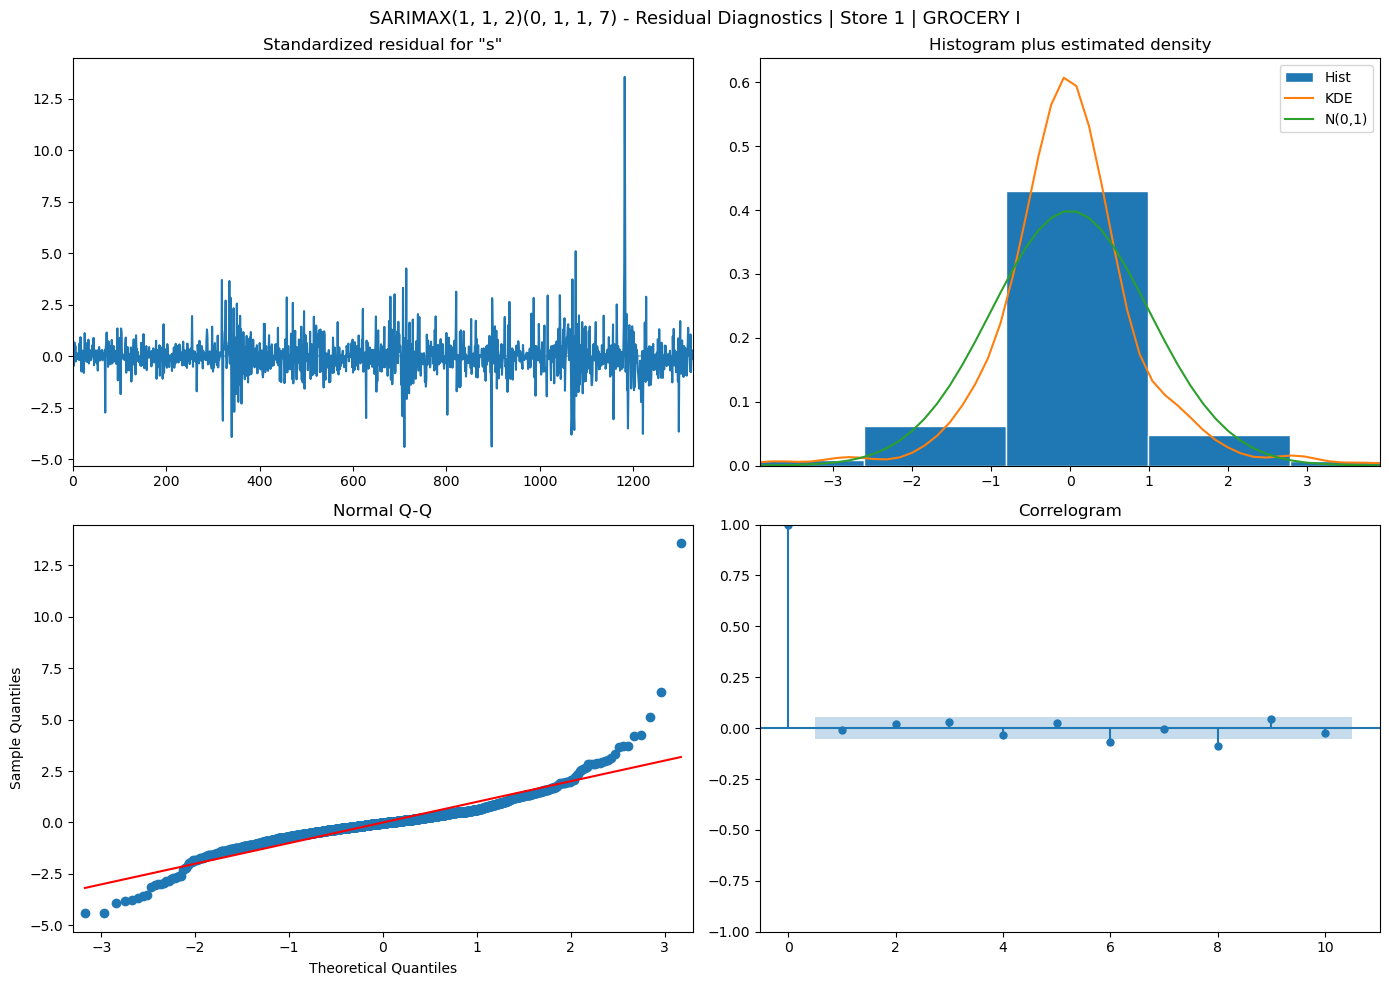


Ljung-Box test (H0: no autocorrelation in residuals):
      lb_stat  lb_pvalue
10  26.140974   0.003555
20  43.780749   0.001610
30  54.471412   0.004072


In [11]:
# Residual diagnostics of best SARIMAX
fig = best_result.plot_diagnostics(figsize=(14, 10))
fig.suptitle(f"SARIMAX{best_order}{best_sorder} - Residual Diagnostics | Store {STORE} | {FAMILY}", fontsize=13)
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(best_result.resid, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box test (H0: no autocorrelation in residuals):")
print(lb)

In [12]:
# 3 models comparison table
comparison = pd.DataFrame([
    {
        "Model" : f"SARIMA{sarima_order}{sarima_seasonal_order}",
        "AIC"   : round(aic_sarima,  2),
        "MAE"   : round(mae_sarima,  2),
        "RMSE"  : round(rmse_sarima, 2),
    },
    {
        "Model" : f"SARIMAX{sarima_order}{sarima_seasonal_order} (full exog)",
        "AIC"   : round(aic_sarimax,  2),
        "MAE"   : round(mae_sarimax,  2),
        "RMSE"  : round(rmse_sarimax, 2),
    },
    {
        "Model" : f"SARIMAX{best_order}{best_sorder} (best grid)",
        "AIC"   : round(best_aic,  2),
        "MAE"   : round(best_mae,  2),
        "RMSE"  : round(best_rmse, 2),
    },
])
print(comparison.to_string(index=False))

                                   Model      AIC    MAE   RMSE
             SARIMA(1, 1, 1)(1, 1, 1, 7) 20251.79 370.85 589.00
SARIMAX(1, 1, 1)(1, 1, 1, 7) (full exog) 20149.30 647.93 875.38
SARIMAX(1, 1, 2)(0, 1, 1, 7) (best grid) 20105.41 644.89 872.63


c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


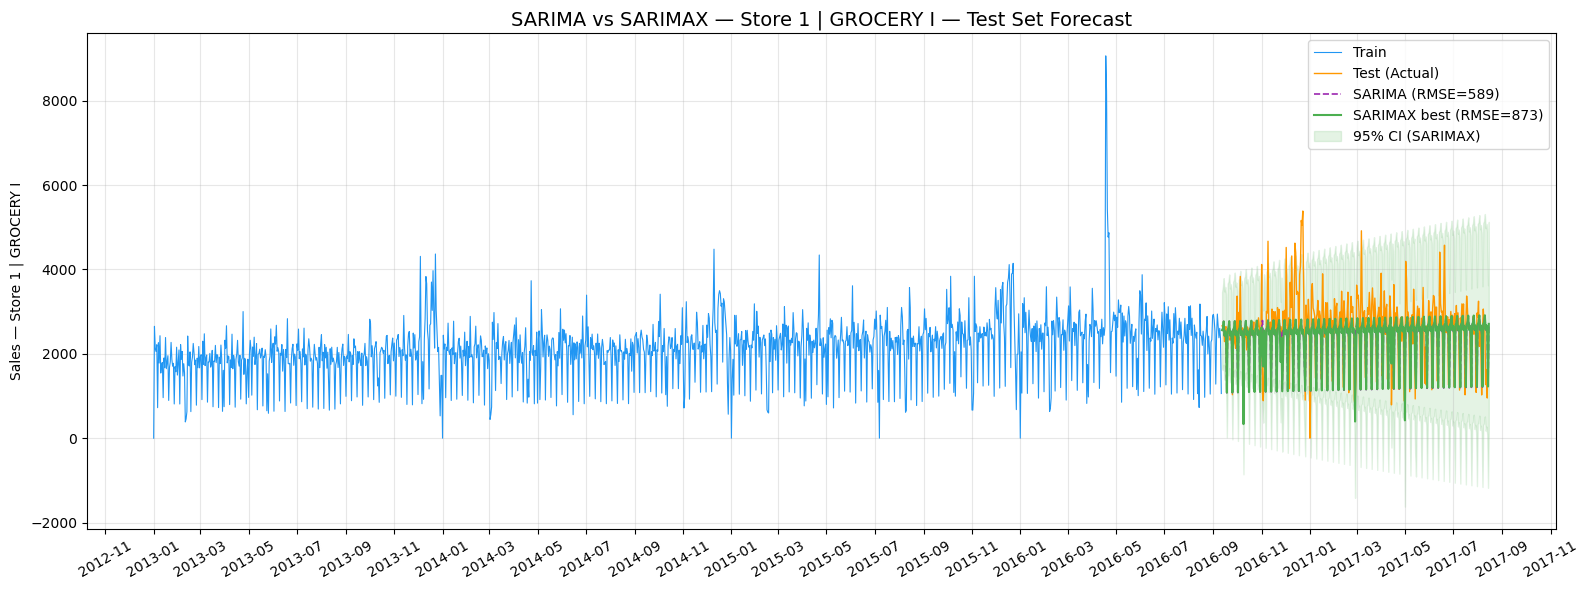

In [13]:
# Plot SARIMA vs SARIMAX best on full test set
best_pred_obj = best_result.get_forecast(steps=len(test), exog=test[EXOG_COLS])
best_pred     = best_pred_obj.predicted_mean
best_ci       = best_pred_obj.conf_int()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train.index, train["sales"], color="#2196F3", linewidth=0.8, label="Train")
ax.plot(test.index,  test["sales"],  color="#FF9800", linewidth=1.0, label="Test (Actual)")
ax.plot(test.index,  sarima_mean,    color="#9C27B0", linewidth=1.2, linestyle="--",
        label=f"SARIMA (RMSE={rmse_sarima:.0f})")
ax.plot(test.index,  best_pred,      color="#4CAF50", linewidth=1.5,
        label=f"SARIMAX best (RMSE={best_rmse:.0f})")
ax.fill_between(
    test.index,
    best_ci.iloc[:, 0], best_ci.iloc[:, 1],
    color="#4CAF50", alpha=0.15, label="95% CI (SARIMAX)"
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.set_title(f"SARIMA vs SARIMAX — Store {STORE} | {FAMILY} — Test Set Forecast", fontsize=14)
ax.set_ylabel(f"Sales — Store {STORE} | {FAMILY}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

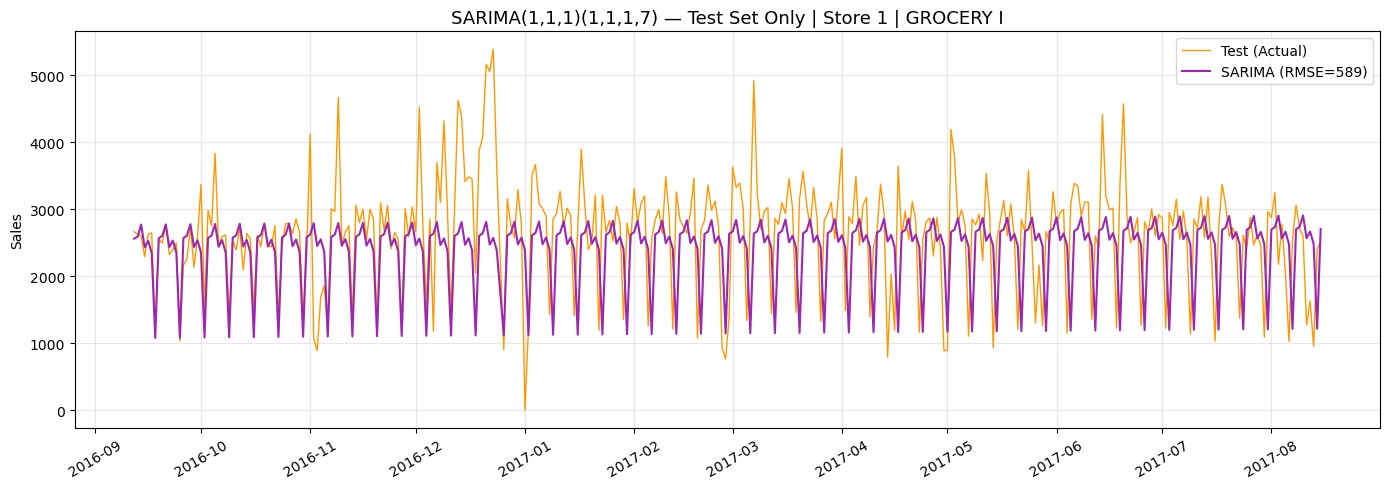

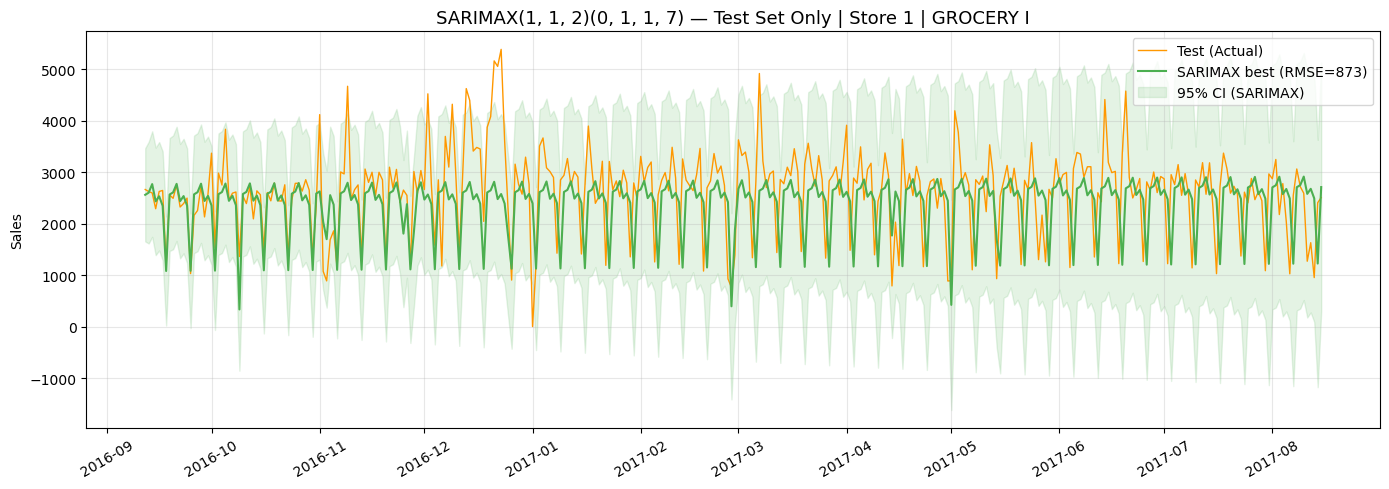

In [14]:
# Zoom in test set — SARIMA
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test["sales"],  color="#FF9800", linewidth=1.0, label="Test (Actual)")
ax.plot(test.index, sarima_mean,    color="#9C27B0", linewidth=1.5,
        label=f"SARIMA (RMSE={rmse_sarima:.0f})")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30)
ax.set_title(f"SARIMA(1,1,1)(1,1,1,7) — Test Set Only | Store {STORE} | {FAMILY}", fontsize=13)
ax.set_ylabel("Sales")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Zoom in test set — SARIMAX best
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test["sales"], color="#FF9800", linewidth=1.0, label="Test (Actual)")
ax.plot(test.index, best_pred,     color="#4CAF50", linewidth=1.5,
        label=f"SARIMAX best (RMSE={best_rmse:.0f})")
ax.fill_between(
    test.index,
    best_ci.iloc[:, 0], best_ci.iloc[:, 1],
    color="#4CAF50", alpha=0.15, label="95% CI (SARIMAX)"
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30)
ax.set_title(f"SARIMAX{best_order}{best_sorder} — Test Set Only | Store {STORE} | {FAMILY}", fontsize=13)
ax.set_ylabel("Sales")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


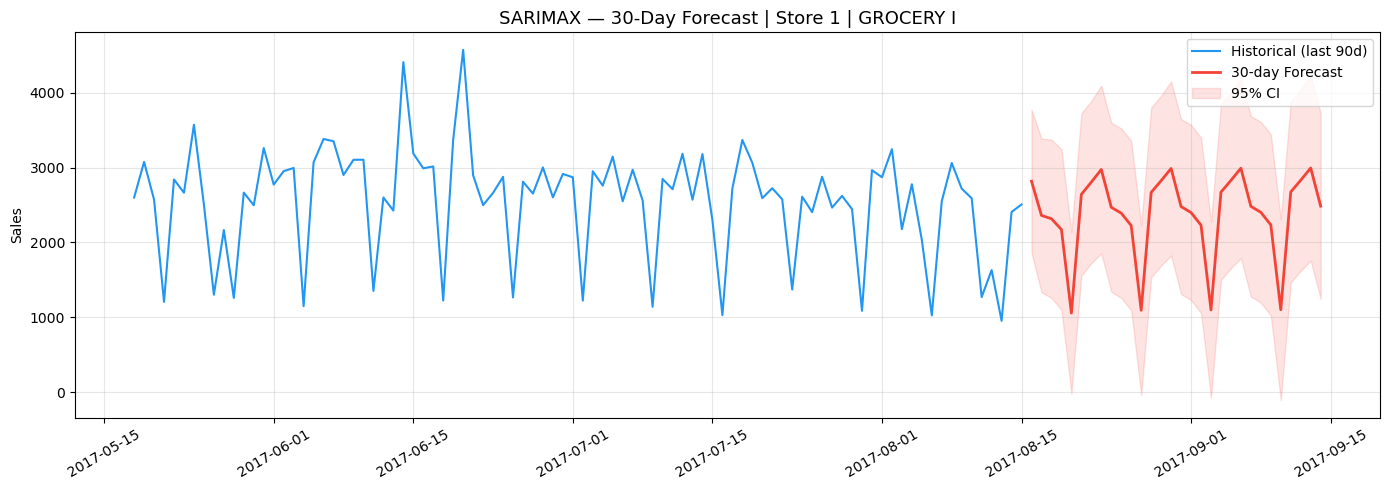

         date  forecast_sales     lower_95     upper_95
0  2017-08-16     2818.557648  1862.335482  3774.779814
1  2017-08-17     2360.978942  1333.893012  3388.064872
2  2017-08-18     2316.679732  1257.848428  3375.511037
3  2017-08-19     2172.780762  1099.296665  3246.264860
4  2017-08-20     1055.858686   -24.484517  2136.201889
5  2017-08-21     2642.720959  1559.139917  3726.302002
6  2017-08-22     2807.002372  1721.882488  3892.122256
7  2017-08-23     2975.631299  1853.454517  4097.808081
8  2017-08-24     2469.453111  1340.416752  3598.489469
9  2017-08-25     2391.848301  1259.566094  3524.130509
10 2017-08-26     2225.124748  1091.294918  3358.954577
11 2017-08-27     1092.560808   -42.013227  2227.134842
12 2017-08-28     2668.703591  1533.767813  3803.639370
13 2017-08-29     2825.638855  1690.524729  3960.752982
14 2017-08-30     2989.233409  1824.647616  4153.819202
15 2017-08-31     2479.605127  1310.134049  3649.076205
16 2017-09-01     2399.635942  1227.839118  3571

In [15]:
# Forecast 30 days future 
daily_full = daily.copy()
daily_full[EXOG_COLS] = daily_full[EXOG_COLS].fillna(0)

final_model = SARIMAX(
    daily_full["sales"],
    exog           = daily_full[EXOG_COLS],
    order          = best_order,
    seasonal_order = best_sorder,
    enforce_stationarity  = False,
    enforce_invertibility = False,
).fit(disp=False)

last_date   = daily_full.index[-1]
future_idx  = pd.date_range(last_date + pd.Timedelta(days=1), periods=30, freq="D")
future_exog = pd.DataFrame({"is_holiday": 0}, index=future_idx)

future_pred = final_model.get_forecast(steps=30, exog=future_exog)
future_mean = future_pred.predicted_mean
future_ci   = future_pred.conf_int()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_full.index[-90:], daily_full["sales"].iloc[-90:],
        color="#2196F3", label="Historical (last 90d)")
ax.plot(future_idx, future_mean, color="#F44336", linewidth=2, label="30-day Forecast")
ax.fill_between(future_idx, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                color="#F44336", alpha=0.15, label="95% CI")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=30)
ax.set_title(f"SARIMAX — 30-Day Forecast | Store {STORE} | {FAMILY}", fontsize=13)
ax.set_ylabel("Sales")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("sarimax_future_forecast.png", dpi=150)
plt.show()

forecast_df = pd.DataFrame({
    "date"          : future_idx,
    "forecast_sales": future_mean.values,
    "lower_95"      : future_ci.iloc[:, 0].values,
    "upper_95"      : future_ci.iloc[:, 1].values,
})
print(forecast_df)